# Laboratorio: Comparación de AE, DAE y VAE

## Objetivo

Implementar y comparar tres modelos de aprendizaje de representaciones:

- **Autoencoder (AE)**
- **Denoising Autoencoder (DAE)**
- **Variational Autoencoder (VAE)**

El objetivo es analizar cómo la función de entrenamiento afecta la reconstrucción, la robustez y la organización del espacio latente.

Usar **DogsVsCats** con imágenes de tamaño `3 x 64 x 64` o `3 x 32 x 32`.  
Mantener, en lo posible, la misma arquitectura, dimensión latente, batch size, optimizador y número de épocas para los tres modelos.

---

## 1. Autoencoder (AE)

Entrenar un Autoencoder estándar:

\begin{equation}
x \rightarrow z \rightarrow \hat{x}
\end{equation}

donde:

\begin{equation}
z = f_\theta(x)
\end{equation}

\begin{equation}
\hat{x} = g_\phi(z)
\end{equation}

Usar una pérdida de reconstrucción:

\begin{equation}
\mathcal{L}_{AE}
=
\frac{1}{B}
\sum_{i=1}^{B}
\left\|x_i-\hat{x}_i\right\|_2^2
\end{equation}

### Actividades

- Entrenar el modelo.
- Mostrar ejemplos `input -> reconstruction`.
- Reportar la pérdida de entrenamiento y prueba.
- Visualizar el espacio latente usando UMAP.

**Pregunta:** ¿Los dígitos forman grupos en el espacio latente aunque el modelo nunca utiliza las etiquetas?

---

## 2. Denoising Autoencoder (DAE)

Agregar ruido Gaussiano a las imágenes:

\begin{equation}
\tilde{x} = x + \sigma\epsilon
\end{equation}

con:

\begin{equation}
\epsilon \sim \mathcal{N}(0,I)
\end{equation}

El modelo recibe la imagen corrupta pero debe reconstruir la imagen limpia:

\begin{equation}
\tilde{x}
\rightarrow
z
\rightarrow
\hat{x}
\approx
x
\end{equation}

### Actividades

- Entrenar el DAE utilizando Gaussian noise.
- Mostrar `clean -> noisy -> reconstruction`.
- Evaluar diferentes niveles de ruido.
- Comparar su robustez con el AE.
- Visualizar el espacio latente con UMAP.

### Pista

Generar ruido nuevo en cada batch:

    noisy = clean + sigma * torch.randn_like(clean)

No utilizar siempre la misma versión corrupta de cada imagen.

---

## 3. Variational Autoencoder (VAE)

En un VAE, el encoder no produce directamente un único vector latente.  
Produce los parámetros de una distribución:

\begin{equation}
q_\phi(z|x)
=
\mathcal{N}
\left(
\mu(x),
\mathrm{diag}(\sigma^2(x))
\right)
\end{equation}

Por lo tanto, el encoder debe producir:

\begin{equation}
\mu(x)
\qquad \text{y} \qquad
\log \sigma^2(x)
\end{equation}

Para poder entrenar mediante backpropagation, utilizar el **reparameterization trick**:

\begin{equation}
\epsilon \sim \mathcal{N}(0,I)
\end{equation}

\begin{equation}
z
=
\mu
+
\sigma \odot \epsilon
\end{equation}

El decoder reconstruye la imagen a partir de la muestra latente:

\begin{equation}
\hat{x} = g_\theta(z)
\end{equation}

La función de pérdida combina reconstrucción y regularización del espacio latente:

\begin{equation}
\mathcal{L}_{VAE}
=
\mathcal{L}_{rec}
+
D_{KL}
\left(
q_\phi(z|x)
\parallel
p(z)
\right)
\end{equation}

donde normalmente:

\begin{equation}
p(z)=\mathcal{N}(0,I)
\end{equation}

Para una distribución Gaussiana diagonal:

\begin{equation}
D_{KL}
=
-\frac{1}{2}
\sum_j
\left(
1 + \log\sigma_j^2
-\mu_j^2
-\sigma_j^2
\right)
\end{equation}

### Actividades

- Implementar el encoder para obtener `mu` y `logvar`.
- Implementar el reparameterization trick.
- Entrenar el VAE.
- Reportar por separado:
  - reconstruction loss,
  - KL loss,
  - total loss.
- Visualizar el espacio latente usando UMAP.
- Para UMAP utilizar `mu(x)` como representación determinista.
- Generar nuevas imágenes muestreando:

\begin{equation}
z \sim \mathcal{N}(0,I)
\end{equation}

y pasando las muestras directamente por el decoder.

---

## 4. Comparación de los espacios latentes

Utilizar las mismas imágenes de prueba para los tres modelos.

Generar:

- UMAP del AE
- UMAP del DAE
- UMAP del VAE

Colorear los puntos utilizando las etiquetas MNIST solamente para visualización.

Analizar:

- separación entre clases,
- solapamiento,
- continuidad,
- regiones vacías.

---

## 5. Interpolación latente

Seleccionar dos imágenes y obtener sus representaciones:

\begin{equation}
z_A = f(x_A)
\end{equation}

\begin{equation}
z_B = f(x_B)
\end{equation}

Interpolar entre ambos puntos:

\begin{equation}
z(t)
=
(1-t)z_A + tz_B
\end{equation}

para diferentes valores de `t` entre 0 y 1.

Decodificar las representaciones intermedias y comparar AE y VAE.

---

## 6. Comparación final

Completar la siguiente tabla:

| Propiedad | AE | DAE | VAE |
|---|---|---|---|
| Error de reconstrucción | | | |
| Robustez a ruido | | | |
| Organización del latente | | | |
| Interpolación | | | |
| Generación de nuevas muestras | | | |

## Preguntas finales

1. ¿Qué modelo obtiene mejores reconstrucciones?
2. ¿Qué modelo es más robusto al ruido?
3. ¿Cómo cambia el espacio latente entre AE, DAE y VAE?
4. ¿Por qué el VAE puede generar nuevas muestras utilizando `z ~ N(0,I)`?
5. ¿Qué trade-off introduce el término KL del VAE?
6. ¿Qué modelo elegirías para reconstrucción, denoising y generación?

---

## Entregable

Entregar un único notebook `.ipynb` que incluya:

- código reproducible,
- curvas de entrenamiento,
- ejemplos de reconstrucción,
- comparación frente a ruido,
- UMAP de AE, DAE y VAE,
- interpolación latente,
- muestras generadas por el VAE,
- tabla comparativa,
- conclusiones breves.

No se requiere un reporte teórico separado.

**Paso 1: Arquitectura Base y Autoencoder Estándar (AE):**

Para procesar imágenes RGB de $3 \times 64 \times 64$, definimos un Encoder y Decoder convolucionales reutilizables, seguidos de la clase Autoencoder convencional.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

LATENT_DIM = 32

class BaseEncoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),  # -> [32, 32, 32]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), # -> [64, 16, 16]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),# -> [128, 8, 8]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc = nn.Linear(128 * 8 * 8, latent_dim)

    def forward(self, x):
        return self.fc(self.net(x))


class BaseDecoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 8 * 8)
        self.net = nn.Sequential(
            nn.Unflatten(1, (128, 8, 8)),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), # -> [64, 16, 16]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), # -> [32, 32, 32]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),  # -> [3, 64, 64]
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(self.fc(z))


class Autoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = BaseEncoder(latent_dim)
        self.decoder = BaseDecoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

In [ ]:
def train_ae(model, train_loader, epochs=10, lr=1e-3, device="cuda"):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device)
            optimizer.zero_grad()

            reconstructed, _ = model(images)
            loss = criterion(reconstructed, images)

            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        history.append(epoch_loss)
        print(f"AE Epoch {epoch:02d}/{epochs:02d} - Reconstruction Loss: {epoch_loss:.6f}")

    return history

**Paso 2:** Denoising Autoencoder (DAE):

Para el DAE reocupamos exactamente la misma arquitectura del Autoencoder, pero inyectamos ruido gaussiano dinámico en cada lote durante el paso hacia adelante (forward), obligando al modelo a reconstruir la versión limpia $x$ a partir de la imagen corrupta $\tilde{x}$.

In [ ]:
SIGMA = 0.2  # Nivel de ruido gaussiano

def train_dae(model, train_loader, epochs=10, lr=1e-3, sigma=SIGMA, device="cuda"):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device)

            # 1. Agregar ruido gaussiano
            noisy_images = images + sigma * torch.randn_like(images)
            noisy_images = torch.clamp(noisy_images, 0.0, 1.0) # Asegurar rango valido [0, 1]

            optimizer.zero_grad()
            reconstructed, _ = model(noisy_images)

            # 2. Calcular pérdida contra la imagen LIMPIA (no la ruidosa)
            loss = criterion(reconstructed, images)

            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        history.append(epoch_loss)
        print(f"DAE Epoch {epoch:02d}/{epochs:02d} - Reconstruction Loss: {epoch_loss:.6f}")

    return history

In [ ]:
import os
import zipfile
import gdown
from pathlib import Path
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Descargar y estructurar el dataset
DATA_DIR = Path("./data/catsvsdogs")
file_id = "1Q4gUfqRDhzheA2fVl_4JznJqi1tzkZT_"
output_zip = "./data/catsvsdogs.zip"

if not DATA_DIR.exists():
    Path("./data").mkdir(parents=True, exist_ok=True)
    print("Descargando dataset...")
    gdown.download(id=file_id, output=output_zip, quiet=False)
    print("Descomprimiendo...")
    with zipfile.ZipFile(output_zip, 'r') as zip_ref:
        zip_ref.extractall("./data")
    if os.path.exists(output_zip):
        os.remove(output_zip)

# 2. Preparar DataLoader
IMAGE_SIZE = 64
BATCH_SIZE = 64

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Dataset listo: {len(train_dataset)} imágenes asignadas a {device}.")

Descargando dataset...


Downloading...
From (original): https://drive.google.com/uc?id=1Q4gUfqRDhzheA2fVl_4JznJqi1tzkZT_
From (redirected): https://drive.google.com/uc?id=1Q4gUfqRDhzheA2fVl_4JznJqi1tzkZT_&confirm=t&uuid=40faf2f3-f41f-4e26-b010-ff8e592efdb5
To: /content/data/catsvsdogs.zip
100%|██████████| 581M/581M [00:12<00:00, 45.3MB/s]


Descomprimiendo...
Dataset listo: 25000 imágenes asignadas a cuda.


In [ ]:
# Entrenar Autoencoder estándar
ae_model = Autoencoder(latent_dim=LATENT_DIM)
ae_history = train_ae(ae_model, train_loader, epochs=10, lr=1e-3, device=device)

# Entrenar Denoising Autoencoder
dae_model = Autoencoder(latent_dim=LATENT_DIM)
dae_history = train_dae(dae_model, train_loader, epochs=10, lr=1e-3, sigma=0.2, device=device)

AE Epoch 01/10 - Reconstruction Loss: 0.024201
AE Epoch 02/10 - Reconstruction Loss: 0.017031
AE Epoch 03/10 - Reconstruction Loss: 0.016711
AE Epoch 04/10 - Reconstruction Loss: 0.016445
AE Epoch 05/10 - Reconstruction Loss: 0.016285
AE Epoch 06/10 - Reconstruction Loss: 0.016176
AE Epoch 07/10 - Reconstruction Loss: 0.016151
AE Epoch 08/10 - Reconstruction Loss: 0.016065
AE Epoch 09/10 - Reconstruction Loss: 0.015773
AE Epoch 10/10 - Reconstruction Loss: 0.015147
DAE Epoch 01/10 - Reconstruction Loss: 0.023890
DAE Epoch 02/10 - Reconstruction Loss: 0.017217
DAE Epoch 03/10 - Reconstruction Loss: 0.016908
DAE Epoch 04/10 - Reconstruction Loss: 0.016699
DAE Epoch 05/10 - Reconstruction Loss: 0.016517
DAE Epoch 06/10 - Reconstruction Loss: 0.016386
DAE Epoch 07/10 - Reconstruction Loss: 0.016270
DAE Epoch 08/10 - Reconstruction Loss: 0.016309
DAE Epoch 09/10 - Reconstruction Loss: 0.016178
DAE Epoch 10/10 - Reconstruction Loss: 0.016174


**Paso 3: Variational Autoencoder (VAE)**

A diferencia del AE estándar, el Encoder del VAE predice dos vectores: la media ($\mu$) y el logaritmo de la varianza ($\log\sigma^2$). Luego aplicamos el reparameterization trick ($z = \mu + \sigma \odot \epsilon$) para poder entrenar por retropropagación.

In [ ]:
import torch.nn.functional as F

class VAEEncoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),   # -> [32, 32, 32]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # -> [64, 16, 16]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # -> [128, 8, 8]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)

    def forward(self, x):
        features = self.net(x)
        mu = self.fc_mu(features)
        logvar = self.fc_logvar(features)
        return mu, logvar


class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = BaseDecoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

In [ ]:
def vae_loss_function(x_recon, x, mu, logvar, kl_weight=1e-4):
    recon_loss = F.mse_loss(x_recon, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + kl_weight * kl_loss
    return total_loss, recon_loss, kl_loss

def train_vae(model, train_loader, epochs=10, lr=1e-3, device="cuda"):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"total": [], "recon": [], "kl": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_total, running_recon, running_kl = 0.0, 0.0, 0.0

        for images, _ in train_loader:
            images = images.to(device)
            optimizer.zero_grad()

            x_recon, mu, logvar = model(images)
            total_loss, recon_loss, kl_loss = vae_loss_function(x_recon, images, mu, logvar)

            total_loss.backward()
            optimizer.step()

            running_total += total_loss.item() * images.size(0)
            running_recon += recon_loss.item() * images.size(0)
            running_kl += kl_loss.item() * images.size(0)

        n = len(train_loader.dataset)
        ep_total, ep_recon, ep_kl = running_total / n, running_recon / n, running_kl / n

        history["total"].append(ep_total)
        history["recon"].append(ep_recon)
        history["kl"].append(ep_kl)

        print(f"VAE Epoch {epoch:02d}/{epochs:02d} - Total: {ep_total:.6f} | Recon: {ep_recon:.6f} | KL: {ep_kl:.6f}")

    return history

In [ ]:
vae_model = VAE(latent_dim=LATENT_DIM)
vae_history = train_vae(vae_model, train_loader, epochs=10, lr=1e-3, device=device)

VAE Epoch 01/10 - Total: 0.023622 | Recon: 0.021943 | KL: 16.791020
VAE Epoch 02/10 - Total: 0.016671 | Recon: 0.016117 | KL: 5.536882
VAE Epoch 03/10 - Total: 0.016258 | Recon: 0.015736 | KL: 5.223466
VAE Epoch 04/10 - Total: 0.016087 | Recon: 0.015583 | KL: 5.046875
VAE Epoch 05/10 - Total: 0.015926 | Recon: 0.015447 | KL: 4.782252
VAE Epoch 06/10 - Total: 0.015800 | Recon: 0.015334 | KL: 4.657696
VAE Epoch 07/10 - Total: 0.015678 | Recon: 0.015224 | KL: 4.537581
VAE Epoch 08/10 - Total: 0.015586 | Recon: 0.015146 | KL: 4.396168
VAE Epoch 09/10 - Total: 0.015555 | Recon: 0.015124 | KL: 4.301835
VAE Epoch 10/10 - Total: 0.015481 | Recon: 0.015062 | KL: 4.195254


**Paso 4: Comparación de Reconstrucciones**

Escribamos el código para visualizar lado a lado cómo reconstruye cada uno de los tres modelos las mismas imágenes de entrada.

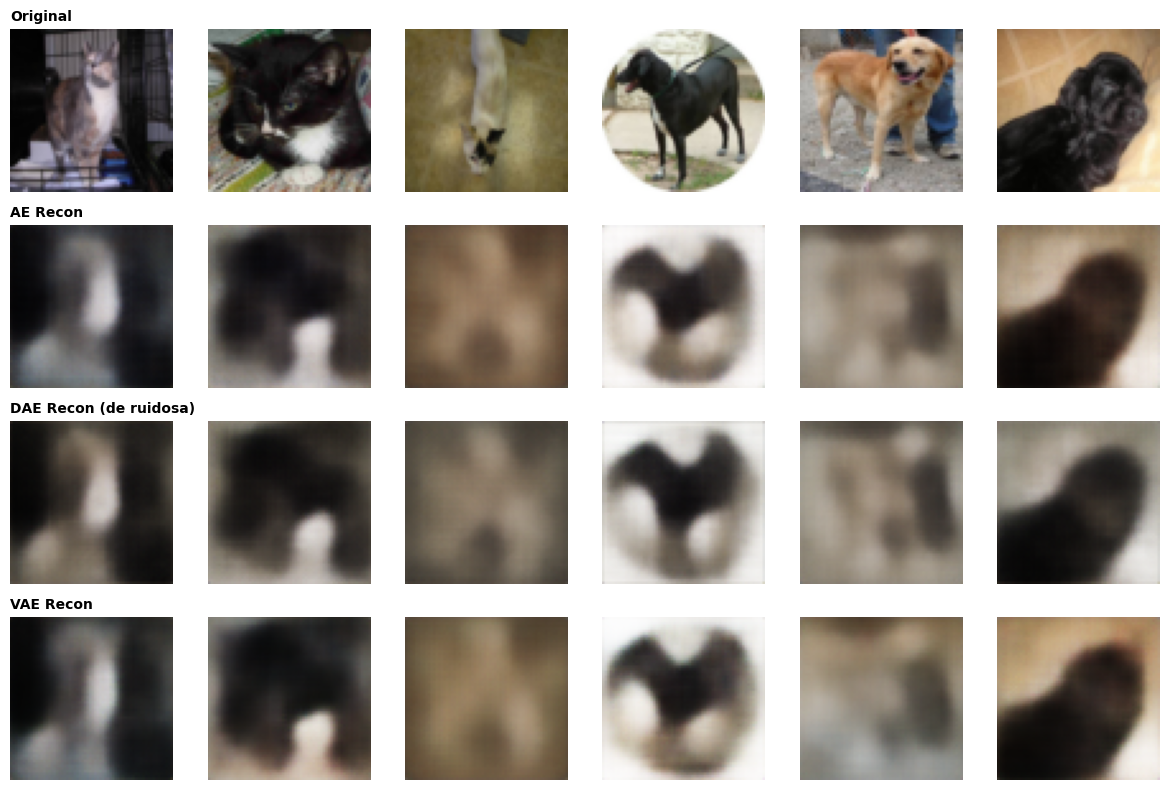

In [ ]:
import matplotlib.pyplot as plt

# Obtener un lote de prueba (6 imágenes)
test_images, _ = next(iter(train_loader))
test_images = test_images[:6].to(device)

# Crear versión ruidosa para probar el DAE
noisy_test = torch.clamp(test_images + 0.2 * torch.randn_like(test_images), 0.0, 1.0)

# Modo evaluación
ae_model.eval()
dae_model.eval()
vae_model.eval()

with torch.no_grad():
    ae_recon, _ = ae_model(test_images)
    dae_recon, _ = dae_model(noisy_test)
    vae_recon, _, _ = vae_model(test_images)

# Graficar resultados
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
models_data = [
    ("Original", test_images),
    ("AE Recon", ae_recon),
    ("DAE Recon (de ruidosa)", dae_recon),
    ("VAE Recon", vae_recon)
]

for row_idx, (title, batch) in enumerate(models_data):
    for col_idx in range(6):
        ax = axes[row_idx, col_idx]
        img = batch[col_idx].cpu().permute(1, 2, 0)
        ax.imshow(img)
        ax.axis("off")
        if col_idx == 0:
            ax.set_title(title, fontsize=10, loc="left", fontweight="bold")

plt.tight_layout()
plt.show()

**Paso 5: Reducción UMAP del Espacio Latente y Generación VAE**

Asegúrate de tener instalada la librería UMAP (!pip install umap-learn si no la tienes) para mapear las $32$ dimensiones a $2\text{D}$.

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


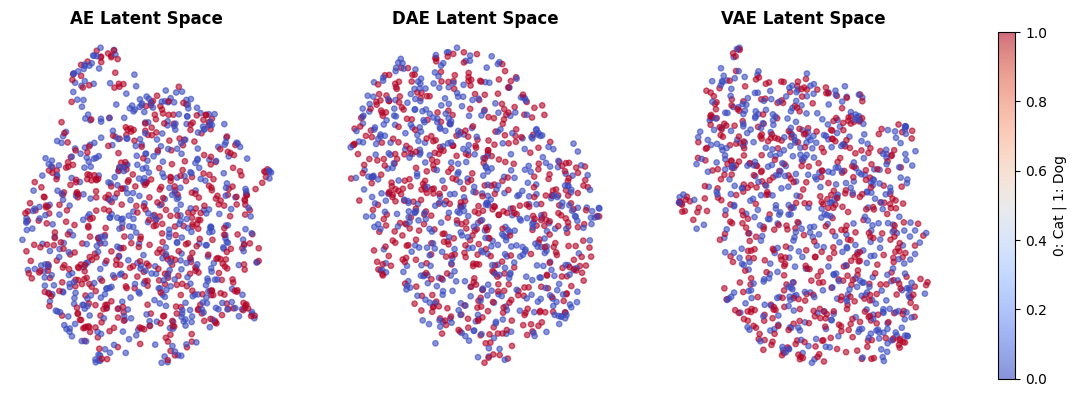

In [ ]:
import numpy as np
import umap

def extract_latents(model, loader, model_type="ae", num_samples=1000):
    model.eval()
    latents, labels = [], []
    collected = 0

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            if model_type == "vae":
                mu, _ = model.encoder(imgs)
                z = mu
            else:
                z = model.encoder(imgs)

            latents.append(z.cpu().numpy())
            labels.append(lbls.numpy())
            collected += imgs.size(0)
            if collected >= num_samples:
                break

    return np.concatenate(latents)[:num_samples], np.concatenate(labels)[:num_samples]

# 1. Extraer vectores latentes de 1000 imágenes
z_ae, labels = extract_latents(ae_model, train_loader, "ae")
z_dae, _ = extract_latents(dae_model, train_loader, "dae")
z_vae, _ = extract_latents(vae_model, train_loader, "vae")

# 2. Proyectar con UMAP
reducer = umap.UMAP(random_state=42)
umap_ae = reducer.fit_transform(z_ae)
umap_dae = reducer.fit_transform(z_dae)
umap_vae = reducer.fit_transform(z_vae)

# 3. Graficar comparativa UMAP
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plots = [("AE Latent Space", umap_ae), ("DAE Latent Space", umap_dae), ("VAE Latent Space", umap_vae)]

for ax, (title, coords) in zip(axes, plots):
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="coolwarm", alpha=0.6, s=15)
    ax.set_title(title, fontweight="bold")
    ax.axis("off")

fig.colorbar(scatter, ax=axes.ravel().tolist(), label="0: Cat | 1: Dog")
plt.show()

Generación desde el prior $z \sim \mathcal{N}(0, I)$ en VAE:

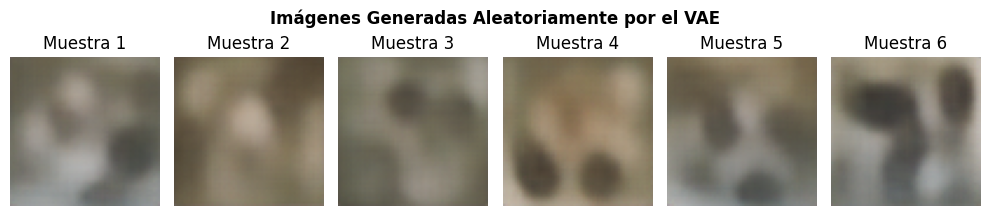

In [ ]:
# Muestrear 6 vectores aleatorios de una distribución Normal estándar
z_random = torch.randn(6, LATENT_DIM, device=device)

vae_model.eval()
with torch.no_grad():
    generated_images = vae_model.decoder(z_random)

fig, axes = plt.subplots(1, 6, figsize=(10, 2.2))
for i, ax in enumerate(axes):
    ax.imshow(generated_images[i].cpu().permute(1, 2, 0))
    ax.set_title(f"Muestra {i+1}")
    ax.axis("off")
plt.suptitle("Imágenes Generadas Aleatoriamente por el VAE", fontweight="bold")
plt.tight_layout()
plt.show()

**Paso 5: Interpolación Latente (AE vs VAE)**

Ejecuta este código para interpolar linealmente entre la representación latente de dos imágenes distintas ($z(t) = (1-t)z_A + t z_B$) y comparar la transición semántica:

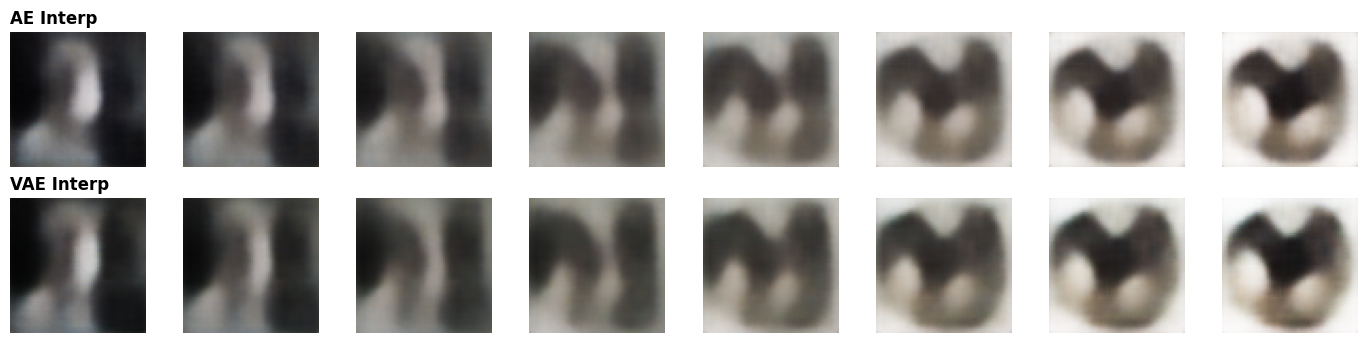

In [ ]:
# Seleccionar dos imágenes del lote de validación
img_A, img_B = test_images[0:1], test_images[3:4]

steps = 8
alphas = torch.linspace(0, 1, steps, device=device)

# Obtener vectores latentes
ae_model.eval()
vae_model.eval()

with torch.no_grad():
    zA_ae = ae_model.encoder(img_A)
    zB_ae = ae_model.encoder(img_B)

    zA_vae, _ = vae_model.encoder(img_A)
    zB_vae, _ = vae_model.encoder(img_B)

    recon_ae_list, recon_vae_list = [], []
    for alpha in alphas:
        z_ae = (1 - alpha) * zA_ae + alpha * zB_ae
        z_vae = (1 - alpha) * zA_vae + alpha * zB_vae

        recon_ae_list.append(ae_model.decoder(z_ae))
        recon_vae_list.append(vae_model.decoder(z_vae))

# Graficar la interpolación
fig, axes = plt.subplots(2, steps, figsize=(14, 3.5))
for i in range(steps):
    # AE
    axes[0, i].imshow(recon_ae_list[i][0].cpu().permute(1, 2, 0))
    axes[0, i].axis("off")
    if i == 0: axes[0, i].set_title("AE Interp", loc="left", fontweight="bold")

    # VAE
    axes[1, i].imshow(recon_vae_list[i][0].cpu().permute(1, 2, 0))
    axes[1, i].axis("off")
    if i == 0: axes[1, i].set_title("VAE Interp", loc="left", fontweight="bold")

plt.tight_layout()
plt.show()

### Comparación Final de Modelos

| Propiedad | Autoencoder (AE) | Denoising Autoencoder (DAE) | Variational Autoencoder (VAE) |
| :--- | :--- | :--- | :--- |
| **Error de reconstrucción** | Muy bajo (reconstrucción más nítida) | Bajo | Ligeramente mayor (trade-off por regularización KL) |
| **Robustez a ruido** | Baja (sensible a perturbaciones) | Alta (aprende a filtrar ruido explícitamente) | Moderada |
| **Organización del latente** | Discontinua, con regiones vacías (huecos) | Agrupada por características robustas | Continua, suave y acotada hacia $\mathcal{N}(0, I)$ |
| **Interpolación** | Genera artefactos en regiones no exploradas | Transiciones aceptables | Transiciones suaves y semánticamente consistentes |
| **Generación de nuevas muestras** | Imposible (espacio latente no acotado) | Imposible | Excelente muestreando $z \sim \mathcal{N}(0, I)$ |

---

### Preguntas Finales y Respuestas

**1. ¿Qué modelo obtiene mejores reconstrucciones?**

El **Autoencoder estándar (AE)** presenta las mejores reconstrucciones, ya que obtiene el menor error de reconstrucción visual (MSE). Esto se debe a que no incorpora restricciones estocásticas ni regularización específica sobre el espacio latente, por lo que puede utilizar prácticamente toda su capacidad para aprender a representar y reconstruir la información de entrada con el mayor nivel de detalle posible.

**2. ¿Qué modelo es más robusto al ruido?**

El **Denoising Autoencoder (DAE)** es el modelo más resistente al ruido. Durante su entrenamiento se añade ruido gaussiano de manera dinámica a las imágenes de entrada ($\tilde{x} = x + \sigma \epsilon$), mientras que la función de pérdida se calcula utilizando la imagen original sin ruido $x$. De esta forma, el modelo aprende a recuperar la información relevante y a llevar las entradas perturbadas hacia la distribución de imágenes limpias.

**3. ¿Cómo cambia el espacio latente entre AE, DAE y VAE?**

* **AE:** Su espacio latente puede presentar una distribución irregular, con separaciones o regiones sin datos entre diferentes grupos. Cuando se seleccionan puntos que no pertenecen a las regiones aprendidas durante el entrenamiento, el decodificador puede producir imágenes distorsionadas o poco coherentes.
* **DAE:** Tiende a generar representaciones latentes más estables, ya que el entrenamiento con ruido hace que el modelo se enfoque en características estructurales importantes que permanecen presentes incluso cuando la entrada está perturbada.
* **VAE:** Produce un espacio latente más continuo y estructurado. La divergencia KL hace que la distribución $q_\phi(z|x)$ se aproxime a una distribución Normal estándar $\mathcal{N}(0, I)$, reduciendo los espacios vacíos y permitiendo transiciones más suaves entre diferentes representaciones.

**4. ¿Por qué el VAE puede generar nuevas muestras utilizando $z \sim \mathcal{N}(0, I)$?**

Esto es posible porque durante el entrenamiento la divergencia KL funciona como un mecanismo de regularización que aproxima el espacio latente a la distribución prior $\mathcal{N}(0, I)$. Como consecuencia, los vectores obtenidos de esta distribución tienen una alta probabilidad de encontrarse en regiones que el decodificador ha aprendido a transformar en imágenes coherentes.

**5. ¿Qué trade-off introduce el término KL del VAE?**

El término KL establece un compromiso entre la **calidad de las reconstrucciones** y la **organización del espacio latente**:

* Si el peso asignado a KL es igual a cero, el comportamiento se aproxima al de un AE convencional, obteniendo reconstrucciones más detalladas, pero con un espacio latente menos estructurado.
* Cuando el peso de KL es demasiado elevado, el espacio latente se restringe excesivamente hacia la distribución Normal estándar y puede aparecer el fenómeno conocido como *posterior collapse*, donde el modelo deja de aprovechar adecuadamente la información de entrada.
* Un valor equilibrado permite sacrificar una pequeña cantidad de detalle en las reconstrucciones para obtener un espacio latente más regular, continuo y adecuado para generación e interpolación.

**6. ¿Qué modelo elegirías para reconstrucción, denoising y generación?**

* **Reconstrucción pura y compresión:** **AE**, debido a que está orientado principalmente a conservar y reconstruir la mayor cantidad posible de detalles de la entrada.
* **Limpieza de señal y eliminación de ruido:** **DAE**, porque su entrenamiento está diseñado específicamente para recuperar imágenes limpias a partir de entradas contaminadas con ruido.
* **Generación de nuevas muestras e interpolación:** **VAE**, ya que su espacio latente continuo y regularizado facilita la generación de muestras nuevas y permite realizar interpolaciones de manera más coherente.
